In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from obspy import Inventory, UTCDateTime, read
from obspy.clients.fdsn import Client
import math
processed_dpath = '../processed_data/'

/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_38782/3139110639.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=10)


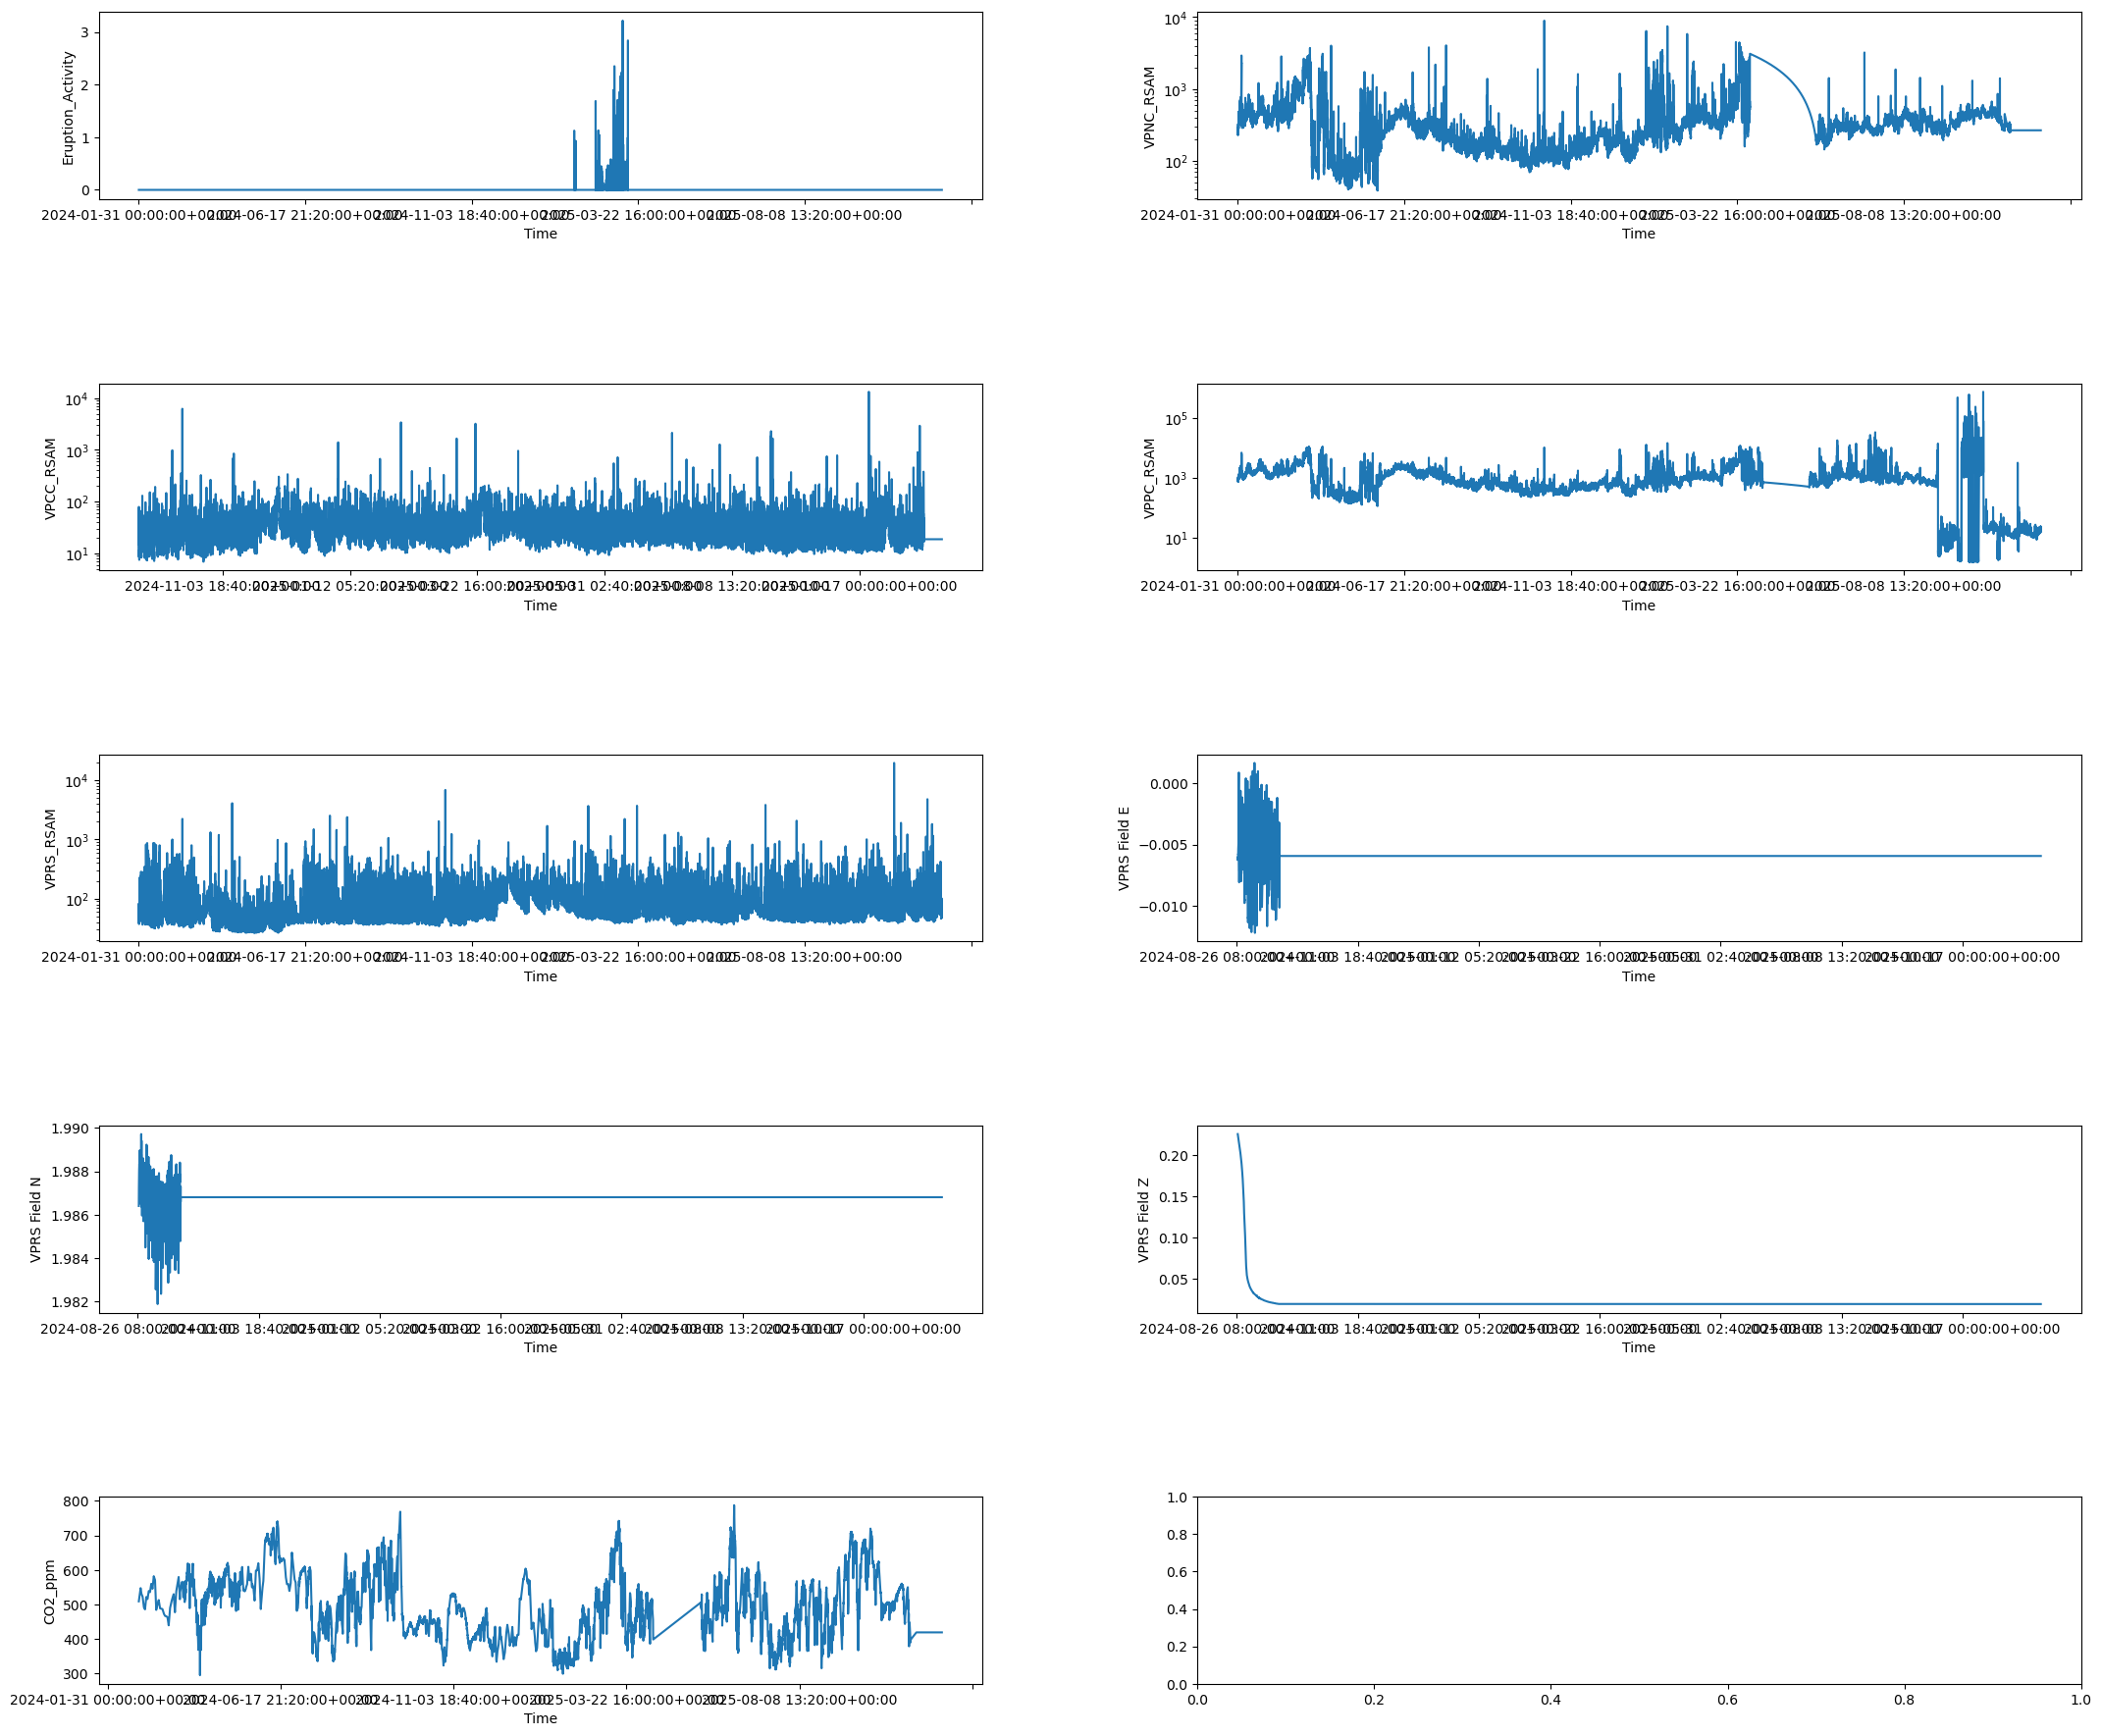

In [2]:
# save combined interpolated data as CSV
interpolated = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)

vars = []
vars.append(interpolated['Eruption_Activity'])
for station in ['VPNC', 'VPCC', 'VPPC', 'VPRS']:
    for channel in ['Z']:
        vars.append(interpolated[f'{station}_RSAM'])
for station in ['VPRS']:
    for channel in ['E', 'N', 'Z']:
        vars.append(interpolated[f'{station} Field {channel}'])
vars.append(interpolated['CO2_ppm'])

scale=3
fig, ax = plt.subplots(math.ceil(len(vars)/2), 2, figsize=(8*scale, 0.75*scale*len(vars)), constrained_layout=True)
ax = ax.flatten()

for ii, v in enumerate(vars):
    v.plot(ax=ax[ii])
    ax[ii].set(ylabel=v.name, xlabel='Time')
    #ax[ii].set(xlim=("2025-01-22 0:0:0.0", "2025-03-15 0:0:0.0"))

ax[1].set_yscale('log')
ax[2].set_yscale('log')
ax[3].set_yscale('log')
ax[4].set_yscale('log')

fig.tight_layout(pad=10)
plt.show()